# 05 — Regression: Predicting pIC50 (Random Forest vs SVR)

**Input:** `data/processed/btk_fps.csv` (4.354 molecules × 2.048 bits)  
**Output:** trained regressors in `models/`, metrics in `results/`

Unlike notebook 04 (binary classification: active/inactive), here we predict
the **continuous pIC50 value** directly. This preserves potency information
lost by the binary threshold — e.g., distinguishing a pIC50=9.5 compound
from a pIC50=6.1 compound, both labeled "active" in the classification task.

Steps:
1. Load fingerprint dataset, prepare X (fingerprints) and y (pIC50)
2. Train/test split
3. Random Forest Regressor — cross-validation
4. SVR — cross-validation
5. Compare CV results
6. Final test set evaluation
7. Predicted vs actual plots
8. Save trained models

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} molecules, {df.shape[1]} columns')

Loaded: 4354 molecules, 2051 columns


## 2. Prepare X and y

- `X`: same 2.048 fingerprint bits as notebook 04
- `y`: now the **continuous `pIC50` value**, not the binary `activity` label

In [2]:
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['pIC50'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'pIC50 range: {y.min():.2f} - {y.max():.2f}')
print(f'pIC50 mean:  {y.mean():.2f} (std: {y.std():.2f})')

X shape: (4354, 2048)
y shape: (4354,)
pIC50 range: 2.00 - 10.15
pIC50 mean:  7.20 (std: 1.20)


## 3. Train/Test Split

No `stratify` needed here — that's a classification concept for balancing
discrete classes. For regression we just do a plain random split.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules')
print(f'Test set:  {X_test.shape[0]} molecules')

Train set: 3483 molecules
Test set:  871 molecules


## 4. Cross-Validation Setup

Plain `KFold` (not stratified — that doesn't apply to continuous targets).
Metrics: **R²** (variance explained, 0-1, higher is better) and
**RMSE** (average error in pIC50 units, lower is better).

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

print('Cross-validation configured: 5-fold KFold')

Cross-validation configured: 5-fold KFold


## 5. Random Forest Regressor — Cross-Validation

In [5]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Running 5-fold cross-validation for Random Forest Regressor...')
rf_cv_results = cross_validate(rf_reg, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== Random Forest Regressor — Cross-Validation Results ===')
print(f"R2:   {rf_cv_results['test_r2'].mean():.3f} \u00b1 {rf_cv_results['test_r2'].std():.3f}")
print(f"RMSE: {-rf_cv_results['test_rmse'].mean():.3f} \u00b1 {rf_cv_results['test_rmse'].std():.3f}")
print(f"MAE:  {-rf_cv_results['test_mae'].mean():.3f} \u00b1 {rf_cv_results['test_mae'].std():.3f}")

Running 5-fold cross-validation for Random Forest Regressor...

=== Random Forest Regressor — Cross-Validation Results ===
R2:   0.745 ± 0.011
RMSE: 0.608 ± 0.022
MAE:  0.445 ± 0.017


## 6. SVR — Cross-Validation

Same scaling rationale as notebook 04: `StandardScaler` inside a Pipeline,
since SVR is sensitive to feature scale (more so than RF).

In [6]:
svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

print('Running 5-fold cross-validation for SVR (this is the slow step)...')
svr_cv_results = cross_validate(svr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== SVR — Cross-Validation Results ===')
print(f"R2:   {svr_cv_results['test_r2'].mean():.3f} \u00b1 {svr_cv_results['test_r2'].std():.3f}")
print(f"RMSE: {-svr_cv_results['test_rmse'].mean():.3f} \u00b1 {svr_cv_results['test_rmse'].std():.3f}")
print(f"MAE:  {-svr_cv_results['test_mae'].mean():.3f} \u00b1 {svr_cv_results['test_mae'].std():.3f}")

Running 5-fold cross-validation for SVR (this is the slow step)...

=== SVR — Cross-Validation Results ===
R2:   0.666 ± 0.022
RMSE: 0.695 ± 0.033
MAE:  0.515 ± 0.029


## 7. Compare CV Results — RF vs SVR

=== CV Comparison (mean across 5 folds) ===
      Random Forest    SVR
R2            0.745  0.666
RMSE          0.608  0.695
MAE           0.445  0.515


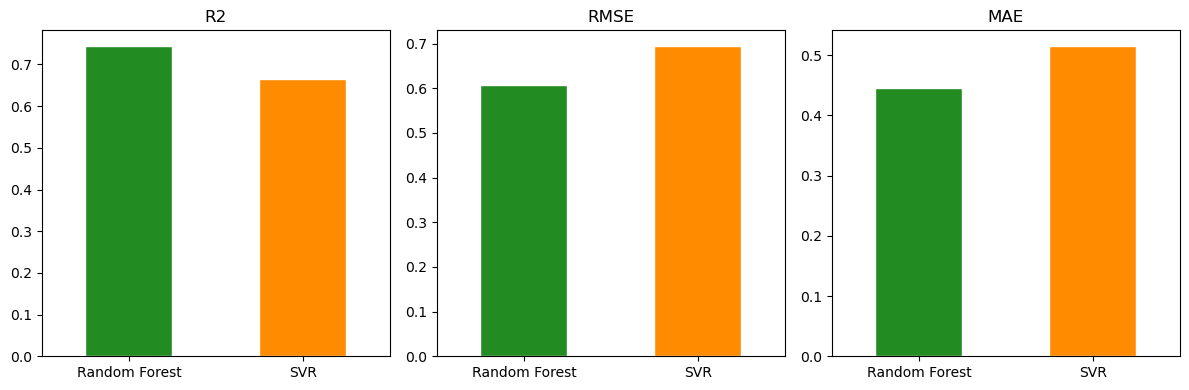

Plot saved to results/


In [7]:
comparison = pd.DataFrame({
    'Random Forest': [
        rf_cv_results['test_r2'].mean(),
        -rf_cv_results['test_rmse'].mean(),
        -rf_cv_results['test_mae'].mean()
    ],
    'SVR': [
        svr_cv_results['test_r2'].mean(),
        -svr_cv_results['test_rmse'].mean(),
        -svr_cv_results['test_mae'].mean()
    ],
}, index=['R2', 'RMSE', 'MAE'])

print('=== CV Comparison (mean across 5 folds) ===')
print(comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, comparison.index):
    comparison.loc[metric].plot(kind='bar', ax=ax, color=['forestgreen', 'darkorange'], edgecolor='white')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../results/05_cv_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Final Training and Test Set Evaluation

In [8]:
rf_reg.fit(X_train, y_train)
svr.fit(X_train, y_train)

rf_pred  = rf_reg.predict(X_test)
svr_pred = svr.predict(X_test)

def print_regression_metrics(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'=== {name} \u2014 Test Set Performance ===')
    print(f'R2:   {r2:.3f}')
    print(f'RMSE: {rmse:.3f}')
    print(f'MAE:  {mae:.3f}')
    print()
    return r2, rmse, mae

rf_r2, rf_rmse, rf_mae   = print_regression_metrics('Random Forest', y_test, rf_pred)
svr_r2, svr_rmse, svr_mae = print_regression_metrics('SVR', y_test, svr_pred)

=== Random Forest — Test Set Performance ===
R2:   0.742
RMSE: 0.602
MAE:  0.438

=== SVR — Test Set Performance ===
R2:   0.687
RMSE: 0.663
MAE:  0.486



## 9. Predicted vs Actual Plots

The closer the points sit to the diagonal line, the better the prediction.
This is the standard visual diagnostic for regression in QSAR.

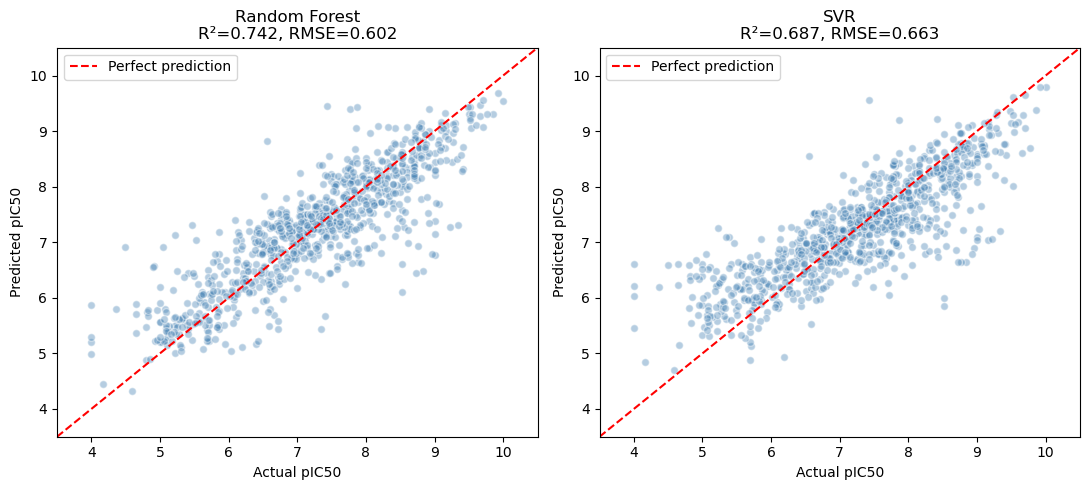

Plot saved to results/


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (name, pred, r2, rmse) in zip(
    axes,
    [('Random Forest', rf_pred, rf_r2, rf_rmse), ('SVR', svr_pred, svr_r2, svr_rmse)]
):
    ax.scatter(y_test, pred, alpha=0.4, color='steelblue', edgecolor='white', s=30)
    lims = [min(y_test.min(), pred.min()) - 0.5, max(y_test.max(), pred.max()) + 0.5]
    ax.plot(lims, lims, linestyle='--', color='red', label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(f'{name}\nR\u00b2={r2:.3f}, RMSE={rmse:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/05_predicted_vs_actual.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 10. Feature Importance (Random Forest Regressor)

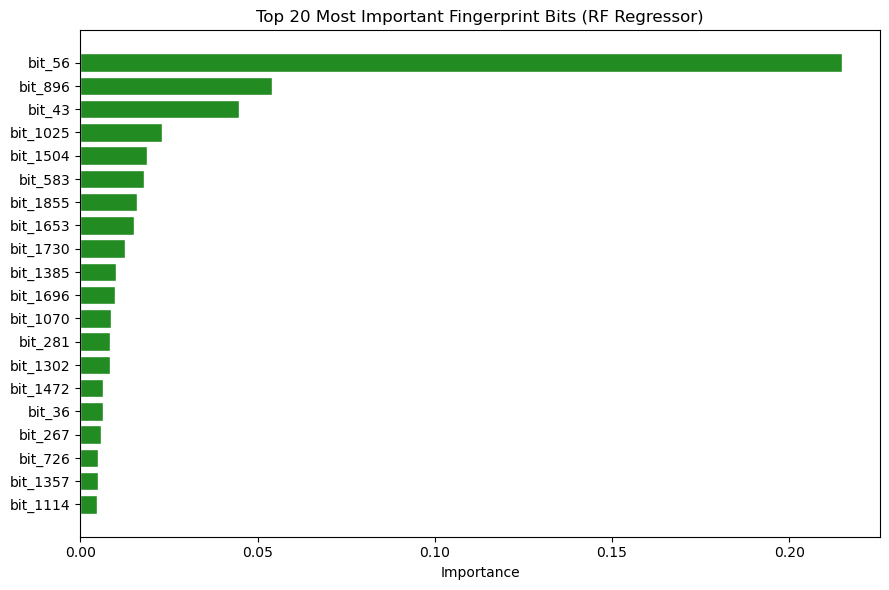

Plot saved to results/

Top bit: bit_56


In [10]:
importances = rf_reg.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(9, 6))
plt.barh(
    [bit_cols[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color='forestgreen', edgecolor='white'
)
plt.title(f'Top {top_n} Most Important Fingerprint Bits (RF Regressor)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/05_feature_importance.png', dpi=150)
plt.show()
print('Plot saved to results/')
print(f'\nTop bit: {bit_cols[top_idx[0]]}')

## 11. Save Trained Models

In [11]:
joblib.dump(rf_reg, '../models/rf_btk_regressor.pkl')
joblib.dump(svr, '../models/svr_btk_regressor.pkl')

print('Models saved:')
print('  models/rf_btk_regressor.pkl')
print('  models/svr_btk_regressor.pkl')

Models saved:
  models/rf_btk_regressor.pkl
  models/svr_btk_regressor.pkl


## Observations

### Performance comparison (test set)

| Metric | Random Forest | SVR |
|--------|---------------|-----|
| R² | 0.742 | 0.687 |
| RMSE | 0.602 | 0.663 |
| MAE | 0.438 | 0.486 |

**Random Forest outperformed SVR on every metric**, and the gap here is
notably larger than in the classification task (notebook 04) — roughly
5.5 percentage points in R² versus ~1.5 in AUC. This reinforces the pattern
seen throughout the project: with high-dimensional sparse binary fingerprints
(2.048 features), tree-based ensembles handle the feature space more
effectively than kernel methods like SVR.

An R² of 0.742 is a strong result for classical QSAR regression — the
literature commonly considers 0.6–0.7 a satisfactory benchmark for
fingerprint-based models, and this exceeds it. An RMSE of 0.602 means
predictions are off by about 0.6 pIC50 units on average — roughly a
4-fold error margin in IC50 concentration, which is reasonable for a
model built purely from 2D structure, with no 3D conformational or
binding-pocket information.

### Strongest evidence of a chemically meaningful model: bit_56

The feature importance plot shows **bit_56 dominating** with an importance
of ~0.21 — more than 4x higher than the second most important feature
(bit_896, ~0.05). This is the same bit identified as the top predictor in
the classification task (notebook 04), where we decoded it as a
**urea/amide-centered substructure** (–NH–C(=O)–NH–), matching the
chemotype of the most potent compound inspected in notebook 03.

The fact that this exact bit emerges as the dominant signal in **two
independently trained models, solving two different tasks** (binary
classification and continuous regression) is strong evidence that the
model is not learning noise or dataset artifacts — it converged on a
real structure-activity relationship. Urea/amide groups are well known
hydrogen-bond donors/acceptors that interact with the hinge region of
kinase ATP-binding pockets, so this result aligns with established
kinase medicinal chemistry, not just statistical correlation.

### Limitations

**1. Class/value imbalance carries over from classification.** The pIC50
distribution is skewed toward active compounds (mean 7.2, see notebook 02),
so the model has seen many more examples in the 6–9 range than at the
extremes. This shows up directly in the predicted-vs-actual plots: both
models track the diagonal well in the 6–9 range, but **systematically
compress predictions toward the mean at the extremes** (pIC50 < 5 or > 9.5).
In other words, the models are more reliable for "typical" compounds in
this dataset and less reliable for unusually weak or unusually potent ones —
exactly the candidates that matter most in a real drug discovery screening
funnel.

**2. Random Forest's extrapolation limit.** This compression effect is
expected for tree-based models: RF predictions are bounded by the range
of target values seen during training and cannot extrapolate beyond it.
SVR shows the same tendency to a lesser degree, but neither model should
be trusted to predict potency for compounds structurally very different
from anything in the BTK training set.

**3. 2D fingerprints carry no 3D information.** ECFP4 encodes substructure
topology, not 3D conformation or binding geometry. Two molecules with very
different 3D shapes could share similar fingerprint bits, and the model
has no way to distinguish them. This is an inherent ceiling of classical
QSAR with circular fingerprints, not a flaw specific to this implementation.

**4. No applicability domain analysis yet.** We have not yet quantified
*how similar* a new query molecule needs to be to the training set for
predictions to be trustworthy. This is a natural next step before using
either model for real virtual screening.

## Summary

| Item | Value |
|------|-------|
| Training set | *(see output)* molecules |
| Test set | *(see output)* molecules |
| RF — Test R² | *(see output)* |
| SVR — Test R² | *(see output)* |
| RF — Test RMSE | *(see output)* |
| SVR — Test RMSE | *(see output)* |

**Next:** hyperparameter tuning (GridSearchCV) for both classification and
regression models, and addressing class imbalance in the classifier.